#Loading Data

In [2]:
import kagglehub # kagglehub gives us the dataset
import os # this allows us to work with file paths
import pandas as pd # allows us to define dataframes
import numpy as np # allows us to define NumPy arrays

# download the dataset directory
dataset_dir = kagglehub.dataset_download("epicskills/tox21-dataset")

# construct the path to the data (a CSV file)
dataset_path = os.path.join(dataset_dir, "tox21.csv")

# Load the (comma seperated) CSV into a pandas DataFrame.
df = pd.read_csv(dataset_path, sep=",")

# These are the 12 toxicity assay columns present in the dataset.
ASSAY_COLUMNS = [
    "NR-AR",
    "NR-AR-LBD",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER",
    "NR-ER-LBD",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]


def get_raw_xy(df, assay_name):
    """
    Return the raw (X, y) pair for one chosen assay.

    Parameters
    ----------
    df : pandas.DataFrame
        The full Tox21 dataframe.

    assay_name : str
        The name of one of the 12 assay columns.

    Returns
    -------
    X : np.ndarray of shape (n_rows, 1)
        The raw SMILES strings for all rows.
        We keep X as 2D because scikit-learn usually expects
        X to have shape (number_of_samples, number_of_features).

    y : np.ndarray of shape (n_rows,)
        The raw assay values for all rows. These may include NaN values.

    Notes
    -----
    This function does no cleaning. It just extracts the raw data
    for the chosen assay.
    """

    # Check that the requested assay name is valid
    if assay_name not in ASSAY_COLUMNS:
        raise ValueError(
            f"{assay_name!r} is not one of the 12 assay names.\n"
            f"Choose one of: {ASSAY_COLUMNS}"
        )

    # X consists of the raw SMILES strings from every row.
    X = df[["smiles"]].to_numpy()

    # y consists of the raw values from the chosen assay column.
    # This may include 0, 1, or NaN.
    y = df[assay_name].to_numpy()

    return X, y

def get_clean_xy(df, assay_name):
    """
    Return the cleaned (X, y) pair for one chosen assay.

    Parameters
    ----------
    df : pandas.DataFrame
        The full Tox21 dataframe.

    assay_name : str
        The name of one of the 12 assay columns.

    Returns
    -------
    X_clean : np.ndarray of shape (n_clean_rows, 1)
        The SMILES strings for rows whose assay value is valid.

    y_clean : np.ndarray of shape (n_clean_rows,)
        The cleaned assay labels as integer 0/1 values.
    """

    # First obtain the raw X and y.
    X_raw, y_raw = get_raw_xy(df, assay_name)

    # Convert the raw assay values to numeric form.
    # If a value cannot be interpreted as a number, it becomes NaN.
    y_numeric = pd.to_numeric(pd.Series(y_raw), errors="coerce")

    # A row is valid if its assay value is present and is either 0 or 1.
    valid_mask = y_numeric.notna() & y_numeric.isin([0, 1])

    # Apply the SAME mask to both X and y so they stay aligned.
    X_clean = X_raw[valid_mask.to_numpy()]
    y_clean = y_numeric[valid_mask].astype(int).to_numpy()

    return X_clean, y_clean



100%|██████████| 126k/126k [00:00<00:00, 14.3MB/s]

Extracting files...


# Cleaning Data

In [3]:
def print_assay_statistics(df):
    print("============================================================")
    print("ASSAY DATA STATISTICS")
    print("============================================================")
    print()

    # Loop through the 12 assay names one at a time
    for assay_name in ASSAY_COLUMNS:

        # Get the raw and cleaned datasets for this assay
        X_raw, y_raw = get_raw_xy(df, assay_name)
        X_clean, y_clean = get_clean_xy(df, assay_name)

        # Count rows before and after cleaning
        n_before = len(y_raw)
        n_after = len(y_clean)
        n_removed = n_before - n_after

        # Count the cleaned 0 and 1 labels
        num_0 = int((y_clean == 0).sum())
        num_1 = int((y_clean == 1).sum())

        # Compute proportions among cleaned rows
        prop_1 = num_1 / n_after

        print(f"{assay_name}")
        print(f"  rows before cleaning: {n_before}")
        print(f"  rows after cleaning:  {n_after}")
        print(f"  rows removed:         {n_removed}")
        print(f"  proportion of 1s:     {prop_1:.4f}")
        print()


# Run the summary
#print_assay_statistics(df)

# Feature Extraction

In [4]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 47.5 MB/s eta 0:00:00


In [5]:
from rdkit import Chem # for working with SMILES
from rdkit import RDLogger
from rdkit.Chem import Descriptors, Lipinski, MACCSkeys, rdFingerprintGenerator

RDLogger.DisableLog("rdApp.*") # supress RDKit warnings

def prepare_feature_inputs(X, y):
    """
    Parse the SMILES strings in X, remove rows whose
    SMILES fail RDKit parsing, and return the valid molecules and
    aligned labels.

    Parameters
    ----------
    X : np.ndarray of shape (n_samples, 1)
        A 2D array whose single column contains SMILES strings.

    y : np.ndarray of shape (n_samples,)
        The corresponding assay labels.

    Returns
    -------
    prepared : dict
        A dictionary containing:
          - "smiles_valid": list of valid SMILES strings
          - "mols_valid": list of RDKit molecule objects
          - "y_valid": np.ndarray of aligned labels
    """

    smiles_list = X.ravel().tolist()

    smiles_valid = []
    mols_valid = []
    y_valid = []

    removed = []

    for row_idx, (smiles, label) in enumerate(zip(smiles_list, y)):
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            removed.append((row_idx, smiles))
        else:
            smiles_valid.append(smiles)
            mols_valid.append(mol)
            y_valid.append(label)

    print("============================================================")
    print("RDKit PARSING SUMMARY")
    print("============================================================")
    print(f"Rows given as input: {len(smiles_list)}")
    print(f"Rows successfully parsed: {len(mols_valid)}")
    print(f"Rows removed due to invalid SMILES: {len(removed)}")
    print()

    if removed:
        print("Removed molecules:")
        for row_idx, bad_smiles in removed:
            print(f"  row {row_idx}: {bad_smiles}")
        print()
    else:
        print("No molecules were removed.")
        print()

    return {
        "smiles_valid": smiles_valid,
        "mols_valid": mols_valid,
        "y_valid": np.array(y_valid),
    }

# ------------------------------------------------------------
# STEP 2:
# FEATURE EXTRACTION FUNCTIONS
# Each function now takes the PREPARED object returned above,
# so parsing is not repeated.
# ------------------------------------------------------------

def featurize_descriptors(prepared):
    """
    Build an interpretable descriptor matrix.

    Output shape:
      (n_valid_samples, 8)
    """
    mols = prepared["mols_valid"]
    y = prepared["y_valid"]

    feature_rows = []
    for mol in mols:
        feature_rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHAcceptors(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumRotatableBonds(mol),
            Lipinski.NumAromaticRings(mol),
            Lipinski.NumAliphaticRings(mol),
            Descriptors.TPSA(mol),
        ])

    X_desc = np.array(feature_rows, dtype=float)
    return X_desc, y


def featurize_rdk(prepared, fp_size=2048):
    """
    Build RDKit path-based fingerprints.
    """
    mols = prepared["mols_valid"]
    y = prepared["y_valid"]

    generator = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=fp_size)

    feature_rows = []
    for mol in mols:
        fp = generator.GetFingerprintAsNumPy(mol)
        feature_rows.append(fp)

    X_rdk = np.array(feature_rows, dtype=int)
    return X_rdk, y


def featurize_maccs(prepared):
    """
    Build MACCS fingerprints.

    Output shape:
      (n_valid_samples, 167)
    """
    mols = prepared["mols_valid"]
    y = prepared["y_valid"]

    feature_rows = []
    for mol in mols:
        fp = MACCSkeys.GenMACCSKeys(mol)
        feature_rows.append(np.array(list(fp), dtype=int))

    X_maccs = np.array(feature_rows, dtype=int)
    return X_maccs, y


def featurize_morgan(prepared, radius=2, fp_size=2048):
    """
    Build Morgan fingerprints.
    """
    mols = prepared["mols_valid"]
    y = prepared["y_valid"]

    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=fp_size,
    )

    feature_rows = []
    for mol in mols:
        fp = generator.GetFingerprintAsNumPy(mol)
        feature_rows.append(fp)

    X_morgan = np.array(feature_rows, dtype=int)
    return X_morgan, y


def concatenate_feature_sets(*arrays):
    """
    Horizontally concatenate multiple feature matrices that have
    the same number of rows.

    Example:
        X_combo = concatenate_feature_sets(X_desc, X_maccs)
    """
    return np.concatenate(arrays, axis=1)


# Processing Assays for ML

In [6]:
def assay_cleaning(assay_name):

  # X_clean is still just the cleaned SMILES strings
  # y_clean is the corresponding 0/1 label vector
  X_clean, y_clean = get_clean_xy(df, assay_name)

  print("============================================================")
  print("CHOSEN ASSAY")
  print("============================================================")
  print("Assay:", assay_name)
  print("X_clean shape:", X_clean.shape)
  print("y_clean shape:", y_clean.shape)
  print()

  # This converts valid SMILES strings into RDKit molecule objects
  # and removes any molecules that RDKit cannot parse.
  prepared = prepare_feature_inputs(X_clean, y_clean)

  print("============================================================")
  print("POST-PARSING SUMMARY")
  print("============================================================")
  print("Valid parsed molecules:", len(prepared["mols_valid"]))
  print("Valid labels:", prepared["y_valid"].shape)
  print()

  # Descriptor dataset
  X_desc, y_desc = featurize_descriptors(prepared)

  # RDK fingerprint dataset
  X_rdk, y_rdk = featurize_rdk(prepared, fp_size=2048)

  # MACCS fingerprint dataset
  X_maccs, y_maccs = featurize_maccs(prepared)

  # Morgan fingerprint dataset
  X_morgan, y_morgan = featurize_morgan(prepared, radius=2, fp_size=2048)

  # Descriptors + MACCS
  X_desc_maccs = concatenate_feature_sets(X_desc, X_maccs)

  # Descriptors + Morgan
  X_desc_morgan = concatenate_feature_sets(X_desc, X_morgan)

  # All four feature types together
  X_all_features = concatenate_feature_sets(X_desc, X_rdk, X_maccs, X_morgan)

  #any of y's work - are all the same

  print("============================================================")
  print("FEATURE DATASET SHAPES")
  print("============================================================")

  print("Descriptors")
  print("  X_desc shape: ", X_desc.shape)
  print("  y_desc shape: ", y_desc.shape)
  print("  X_desc null values: ", np.isnan(X_desc).sum())
  print()

  print("RDK fingerprints")
  print("  X_rdk shape:  ", X_rdk.shape)
  print("  y_rdk shape:  ", y_rdk.shape)
  print("  X_rdk null values ", np.isnan(X_rdk).sum())
  print()

  print("MACCS fingerprints")
  print("  X_maccs shape:", X_maccs.shape)
  print("  y_maccs shape:", y_maccs.shape)
  print("  X_maccs null values: ", np.isnan(X_maccs).sum())
  print()

  print("Morgan fingerprints")
  print("  X_morgan shape:", X_morgan.shape)
  print("  y_morgan shape:", y_morgan.shape)
  print("  X_morgan null values: ", np.isnan(X_morgan).sum())
  print()

  print("Combined: descriptors + MACCS")
  print("  X_desc_maccs shape:", X_desc_maccs.shape)
  print()

  print("Combined: descriptors + Morgan")
  print("  X_desc_morgan shape:", X_desc_morgan.shape)
  print()

  print("Combined: all feature sets")
  print("  X_all_features shape:", X_all_features.shape)
  print()

  return {
    "X_desc": X_desc,
    "X_desc_maccs": X_desc_maccs,
    "X_desc_morgan": X_desc_morgan,
    "X_all_features": X_all_features,
    "y_desc": y_desc}


In [7]:
results = {}

'''assay_list = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]'''

assay_list = [
    "NR-ER", "SR-HSE", "SR-MMP"
]
for assay_name in assay_list:
    print(f"Processing assay: {assay_name}")

    results[assay_name] = assay_cleaning(assay_name)

    print("X_desc shape:", results[assay_name]["X_desc"].shape)
    print("============================================================")

Processing assay: NR-ER
CHOSEN ASSAY
Assay: NR-ER
X_clean shape: (6193, 1)
y_clean shape: (6193,)

RDKit PARSING SUMMARY
Rows given as input: 6193
Rows successfully parsed: 6186
Rows removed due to invalid SMILES: 7

Removed molecules:
  row 1815: O=CO[AlH3](OC=O)OC=O
  row 1822: CC(=O)O[AlH3](O)O
  row 2806: CC(=O)O[AlH3](O)OC(C)=O
  row 3623: CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC
  row 3698: CCCCO[AlH3](OCCCC)OCCCC
  row 4360: O=S(=O)(OC[C@H]1O[C@H](O[C@]2(COS(=O)(=O)O[AlH3](O)O)O[C@H](COS(=O)(=O)O[AlH3](O)O)[C@@H](OS(=O)(=O)O[AlH3](O)O)[C@@H]2OS(=O)(=O)O[AlH3](O)O)[C@H](OS(=O)(=O)O[AlH3](O)O)[C@@H](OS(=O)(=O)O[AlH3](O)O)[C@@H]1OS(=O)(=O)O[AlH3](O)O)O[AlH3](O)O.O[AlH3](O)[AlH3](O)O.O[AlH3](O)[AlH3](O)O.O[AlH3](O)[AlH3](O)O.O[AlH3](O)[AlH3](O)O
  row 5292: CCCCCCCCCCCCCCCCCC(=O)O[AlH3](O)O

POST-PARSING SUMMARY
Valid parsed molecules: 6186
Valid labels: (6186,)

FEATURE DATASET SHAPES
Descriptors
  X_desc shape:  (6186, 8)
  y_desc shape:  (6186,)
  X_desc null values:  0

RDK finge

# Benchmarks

In [8]:
#Thiis is the function that runs the evaluation metrics
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def run_benchmarks(X_train, X_test, y_train, y_test, your_model_results):

    results = {}

    # Random Predictor
    random_clf = DummyClassifier(strategy="uniform", random_state=42)
    random_clf.fit(X_train, y_train)
    y_pred = random_clf.predict(X_test)
    results["Random Predictor"] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, random_clf.predict_proba(X_test)[:, 1])
    }

    # majority Class Predictor
    majority_clf = DummyClassifier(strategy="most_frequent")
    majority_clf.fit(X_train, y_train)
    y_pred = majority_clf.predict(X_test)
    results["Majority Class"] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, majority_clf.predict_proba(X_test)[:, 1])
    }

    # single Attribute Classifier
    best_acc = 0
    best_feature = 0
    for i in range(X_train.shape[1]):
        single_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
        single_clf.fit(X_train[:, [i]], y_train)
        acc = accuracy_score(y_test, single_clf.predict(X_test[:, [i]]))
        if acc > best_acc:
            best_acc = acc
            best_feature = i

    single_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    single_clf.fit(X_train[:, [best_feature]], y_train)
    y_pred = single_clf.predict(X_test[:, [best_feature]])
    results["Single Attribute"] = {
        "accuracy": best_acc,
        "auc": roc_auc_score(y_test, single_clf.predict_proba(X_test[:, [best_feature]])[:, 1])
    }

    # Decision Tree Depth 2
    dt2_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
    dt2_clf.fit(X_train, y_train)
    y_pred = dt2_clf.predict(X_test)
    results["Decision Tree (depth=2)"] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, dt2_clf.predict_proba(X_test)[:, 1])
    }

    # our models, put your models "results" output into the function
    results["Your Model"] = {
        "accuracy": 1 - your_model_results["E_out"],
        "auc": your_model_results["AUC"]
    }

    # rint comparison table
    print(f"{'Model':<30} {'Accuracy':>10} {'AUC':>10}")
    print("-" * 52)
    for name, metrics in results.items():
        marker = " <-- YOURS" if name == "Your Model" else ""
        print(f"{name:<30} {metrics['accuracy']:>10.4f} {metrics['auc']:>10.4f}{marker}")

    return results

# SR-MMP Assay

In [9]:
assay_name = "SR-MMP"

X_desc_maccs = results[assay_name]["X_desc_maccs"]
X_desc_morgan = results[assay_name]["X_desc_morgan"]
y_desc = results[assay_name]["y_desc"]

# Random Forest

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    validation_curve,
    cross_val_score
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    roc_curve,
    auc
)


def train_random_forest_model(X, y):

    # cost matrix
    c_fp = 1
    c_fn = 5

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # RF model
    rf = RandomForestClassifier(
        random_state=42,
        bootstrap=True,
        n_jobs=-1
    )

    # parameter grid
    param_grid = {
        "n_estimators": [300, 500],
        "max_depth": [5, 10, 20],
        "min_samples_split": [4, 10],
        "min_samples_leaf": [5, 10],
        "max_features": ["sqrt"],
        "class_weight": ["balanced"]
    }

    # CV setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    # Train
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # Probabilities
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Threshold Optimization
    thresholds = np.arange(0.1, 0.9, 0.01)

    best_threshold = 0.5
    best_cost = float("inf")

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        cost = fp * c_fp + fn * c_fn

        if cost < best_cost:
            best_cost = cost
            best_threshold = t

    y_pred = (y_prob >= best_threshold).astype(int)

    # Metrtics
    acc = accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    total_cost = fp * c_fp + fn * c_fn

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(cm)

    print("\n=== BASIC METRICS ===")
    print("Accuracy:", acc)
    print("Best Threshold:", best_threshold)
    print("Total Cost:", total_cost)

    # ROC-Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_curve = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_curve:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Learning curve
    analysis_model = RandomForestClassifier(**best_params, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=analysis_model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    plt.figure()
    plt.plot(train_sizes, 1 - np.mean(train_scores, axis=1), label="Train Error")
    plt.plot(train_sizes, 1 - np.mean(val_scores, axis=1), label="Val Error")
    plt.xlabel("Training Size")
    plt.ylabel("Error")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()


    # validation curve

    param_range = [5, 10, 20, 40, None]
    x_labels = ["5", "10", "20", "40", "None"]

    train_scores, val_scores = validation_curve(
        estimator=analysis_model,
        X=X_train,
        y=y_train,
        param_name="max_depth",
        param_range=param_range,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    plt.figure()
    plt.plot(x_labels, 1 - np.mean(train_scores, axis=1), label="Train Error")
    plt.plot(x_labels, 1 - np.mean(val_scores, axis=1), label="Val Error")
    plt.xlabel("max_depth")
    plt.ylabel("Error")
    plt.title("Validation Curve")
    plt.legend()
    plt.show()


    # FINAL MODEL EVALUATION

    # Test ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)

    #  Bootstrap CI
    def bootstrap_auc_ci(y_true, y_scores, n_bootstraps=1000, alpha=0.05, seed=42):
        rng = np.random.RandomState(seed)
        scores = []
        n = len(y_true)

        y_true = np.array(y_true)
        y_scores = np.array(y_scores)

        for _ in range(n_bootstraps):
            idx = rng.randint(0, n, n)

            if len(np.unique(y_true[idx])) < 2:
                continue

            scores.append(roc_auc_score(y_true[idx], y_scores[idx]))

        scores = np.array(scores)

        return (
            roc_auc_score(y_true, y_scores),
            np.percentile(scores, 100 * alpha / 2),
            np.percentile(scores, 100 * (1 - alpha / 2))
        )

    roc_auc, auc_lower, auc_upper = bootstrap_auc_ci(y_test, y_prob)

    # Cross-validated AUC
    cv_auc_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    cv_mean = np.mean(cv_auc_scores)
    cv_std = np.std(cv_auc_scores)


    # FINAL REPORT

    print("\n==============================")
    print("Final Model Summary")
    print("==============================")

    print("\n--- Test Performance ---")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Bootstrap 95% CI: [{auc_lower:.3f}, {auc_upper:.3f}]")

    print("\n--- Cross-Validation ---")
    print("CV Scores:", cv_auc_scores)
    print(f"Mean AUC: {cv_mean:.3f}")
    print(f"Std AUC: {cv_std:.3f}")
    print(f"Approx 95% range: [{cv_mean - 2*cv_std:.3f}, {cv_mean + 2*cv_std:.3f}]")

    print("==============================\n")


    # return

    return {
        "model": best_model,
        "best_params": best_params,
        "best_threshold": best_threshold,
        "accuracy": acc,
        "roc_auc": roc_auc,
        "cv_auc_scores": cv_auc_scores,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "total_cost": total_cost,
        "y_test": y_test,
        "y_prob": y_prob,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train
    }

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       977
           1       0.58      0.85      0.69       184

    accuracy                           0.88      1161
   macro avg       0.77      0.87      0.81      1161
weighted avg       0.91      0.88      0.89      1161


Confusion Matrix:
[[863 114]
 [ 28 156]]

=== BASIC METRICS ===
Accuracy: 0.8776916451335056
Best Threshold: 0.4199999999999998
Total Cost: 254


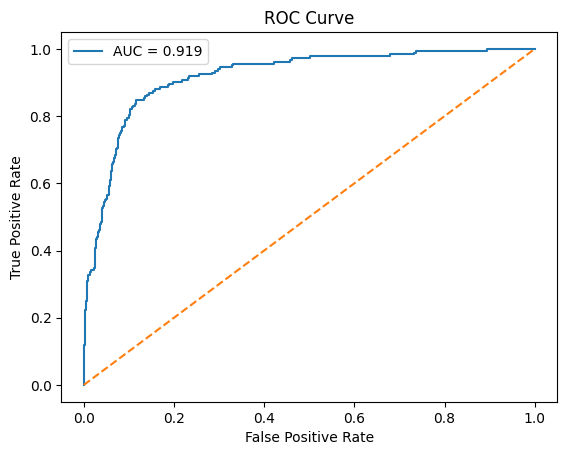

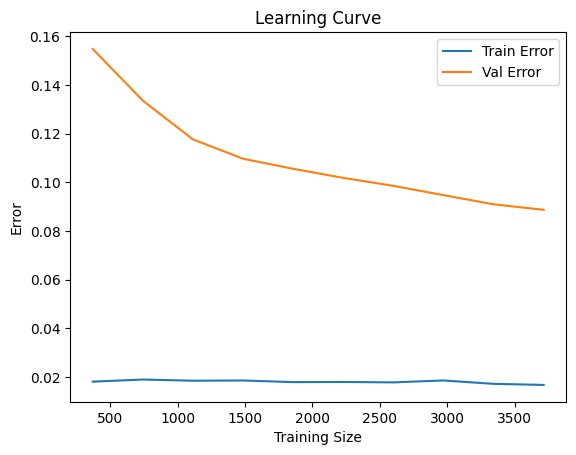

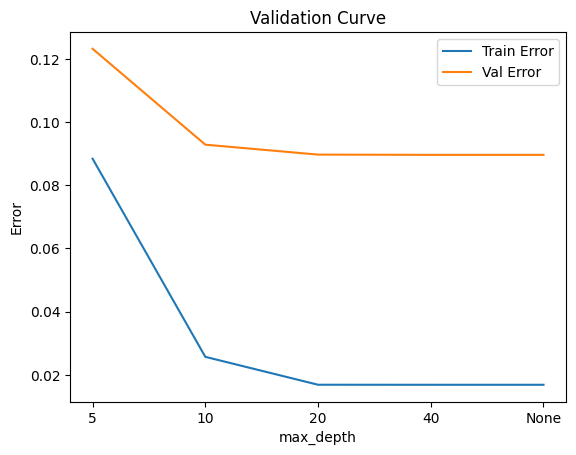


FINAL MODEL SUMMARY

--- Test Performance ---
ROC-AUC: 0.919
Bootstrap 95% CI: [0.896, 0.940]

--- Cross-Validation ---
CV Scores: [0.89444038 0.89861597 0.92733615 0.91664331 0.91467419]
Mean AUC: 0.910
Std AUC: 0.012
Approx 95% range: [0.886, 0.935]



In [ ]:
rf_results = train_random_forest_model(X_desc_maccs, y_desc)

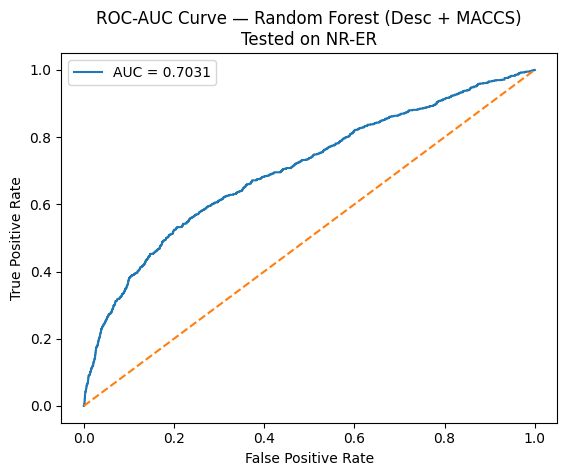

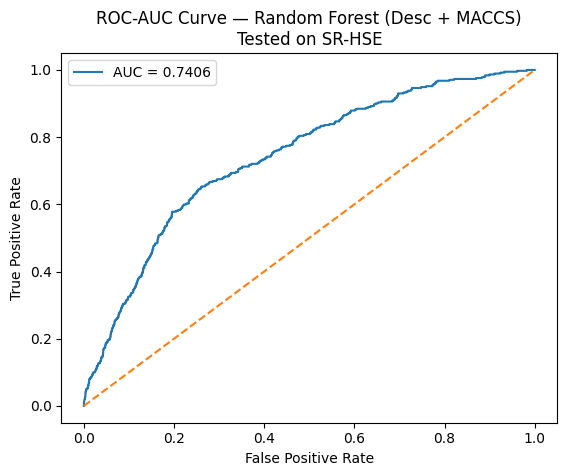

In [ ]:
best_rf_model = rf_results["model"]

for assay_name in results:

    # skip training assay
    if assay_name == "SR-MMP":
        continue

    X_test = results[assay_name]["X_desc_maccs"]
    y_test = results[assay_name]["y_desc"]

    y_prob =best_rf_model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC-AUC Curve — Random Forest (Desc + MACCS)\nTested on {assay_name}")
    plt.legend()
    plt.show()

In [ ]:
rf_results = train_random_forest_model(X_desc_morgan, y_desc)

# Decision Tree

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    learning_curve, validation_curve,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, auc, roc_auc_score
)


def train_bagging_tree_model(results, assay_name="SR-MMP"):

    # =========================
    # COST MATRIX
    # =========================
    c_fp = 1
    c_fn = 5

    # =========================
    # PARAM GRID
    # =========================
    param_dist = {
        "n_estimators": [50, 100, 150],
        "max_samples": [0.7, 1.0],
        "max_features": [0.7, 1.0],
        "estimator__max_depth": [5, 10, None],
        "estimator__min_samples_leaf": [1, 2, 5],
    }

    # =========================
    # DATA
    # =========================
    X_desc_maccs = results[assay_name]["X_desc_maccs"]
    y_desc = results[assay_name]["y_desc"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_desc_maccs, y_desc,
        test_size=0.2,
        stratify=y_desc,
        random_state=42
    )

    # =========================
    # MODEL + SEARCH
    # =========================
    search = RandomizedSearchCV(
        estimator=BaggingClassifier(
            estimator=DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            ),
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=param_dist,
        n_iter=25,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print("\nBest Params:", search.best_params_)

    # =========================
    # PROBABILITIES
    # =========================
    y_prob = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    test_auc = auc(fpr, tpr)

    # =========================
    # THRESHOLD OPTIMIZATION (BEFORE PLOTTING)
    # =========================
    best_t = 0.5
    best_cost = float("inf")

    for t in thresh:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        cost = fp * c_fp + fn * c_fn

        if cost < best_cost:
            best_cost = cost
            best_t = t

     # =========================
    # ROC CURVE + OPERATING POINT
    # =========================
    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    # best threshold point
    y_pred_best = (y_prob >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

    best_fpr = fp / (fp + tn)
    best_tpr = tp / (tp + fn)

    # point
    plt.scatter(best_fpr, best_tpr, color="red", s=100,
                label=f"Best Threshold = {best_t:.3f}")

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC-AUC — Bagging (Desc + MACCS)")
    plt.legend()
    plt.show()



    # LEARNING CURVE
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X_desc_maccs, y_desc,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    plt.figure()
    plt.plot(train_sizes, 1-np.mean(train_scores, axis=1), label="Train AUC")
    plt.plot(train_sizes, 1-np.mean(val_scores, axis=1), label="Val AUC")
    plt.xlabel("Training Size")
    plt.ylabel("Error")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

    # =========================
    # VALIDATION CURVE
    # =========================
    param_range = [3, 5, 7, 10, 15]

    train_scores_v, val_scores_v = validation_curve(
        BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight="balanced"),
            n_estimators=100,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        X_desc_maccs,
        y_desc,
        param_name="estimator__max_depth",
        param_range=param_range,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    )

    plt.figure()
    plt.plot(param_range, 1-np.mean(train_scores_v, axis=1), label="Train AUC")
    plt.plot(param_range, 1-np.mean(val_scores_v, axis=1), label="Val AUC")
    plt.xlabel("Max Depth")
    plt.ylabel("Error")
    plt.title("Generalization Curve")
    plt.legend()
    plt.show()

    # =========================
    # FINAL PREDICTION USING BEST THRESHOLD
    # =========================
    y_pred = (y_prob >= best_t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)

    # =========================
    # CROSS-VALIDATION
    # =========================
    cv_scores = cross_val_score(
        best_model,
        X_desc_maccs,
        y_desc,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)

    # =========================
    # PRINT SUMMARY
    # =========================
    print("\n==============================")
    print("MODEL SUMMARY — BAGGING (Desc + MACCS)")
    print("==============================")

    print("\n--- Test Performance ---")
    print(f"AUC: {test_auc:.3f}")

    print("\n--- Cross-Validation ---")
    print("CV Scores:", cv_scores)
    print(f"Mean AUC: {cv_mean:.3f}")
    print(f"Std AUC: {cv_std:.3f}")
    print(f"Approx 95% range: [{cv_mean - 2*cv_std:.3f}, {cv_mean + 2*cv_std:.3f}]")

    print("\n--- Cost Analysis ---")
    print(cm)
    print(f"FP={fp}, FN={fn}")
    print(f"Best Threshold: {best_t:.4f}")
    print(f"Total Cost: {fp*c_fp + fn*c_fn}")

    # =========================
    # RETURN
    # =========================
    return {
        "model": best_model,
        "auc": test_auc,
        "cv_scores": cv_scores,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "best_threshold": best_t,
        "confusion_matrix": cm
    }

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Params: {'n_estimators': 100, 'max_samples': 1.0, 'max_features': 0.7, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': None}


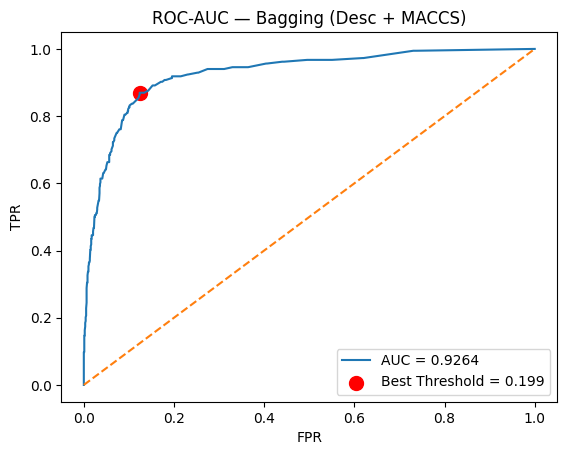

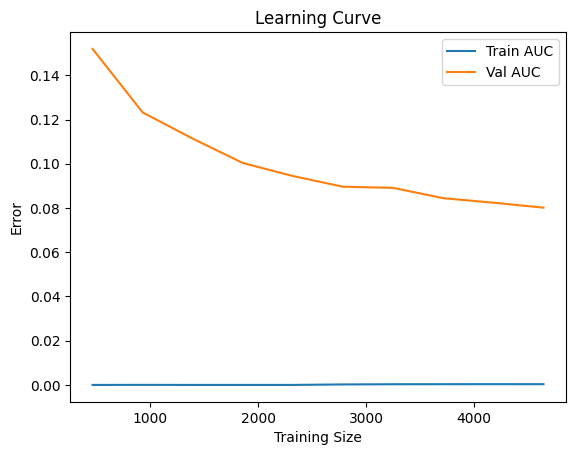

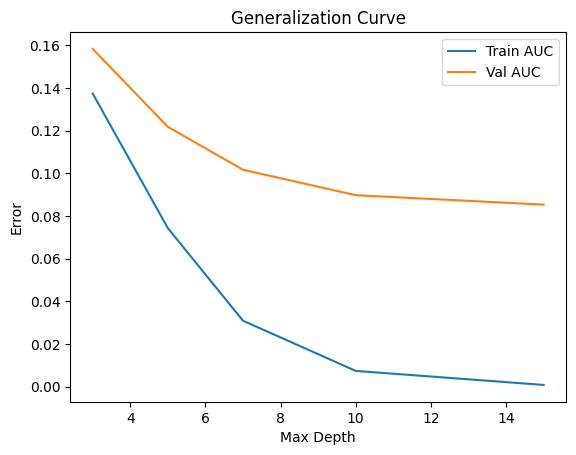


MODEL SUMMARY — BAGGING (Desc + MACCS)

--- Test Performance ---
AUC: 0.926

--- Cross-Validation ---
CV Scores: [0.9249919  0.91845879 0.91395577 0.92183815 0.9262323 ]
Mean AUC: 0.921
Std AUC: 0.004
Approx 95% range: [0.912, 0.930]

--- Cost Analysis ---
[[856 121]
 [ 24 160]]
FP=121, FN=24
Best Threshold: 0.1994
Total Cost: 241


In [15]:
results_bagging = train_bagging_tree_model(results, assay_name="SR-MMP")

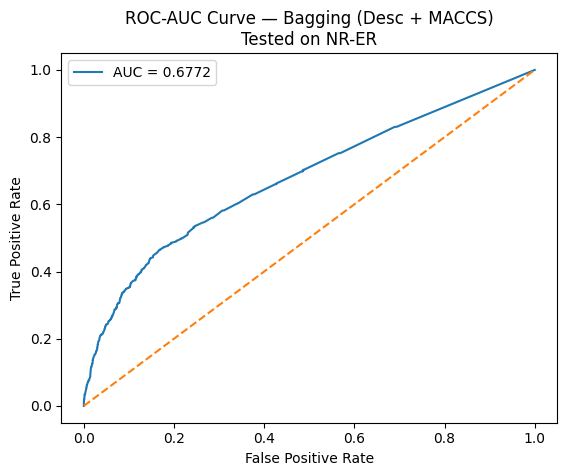

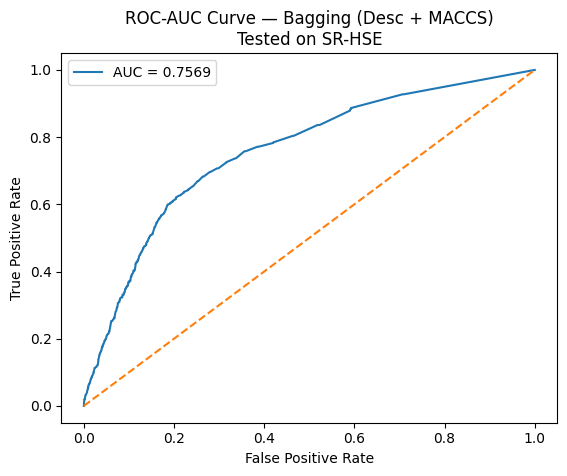

In [ ]:
best_bagging_model = results_bagging["model"]

for assay_name in results:

    # skip training assay
    if assay_name == "SR-MMP":
        continue

    X_test = results[assay_name]["X_desc_maccs"]
    y_test = results[assay_name]["y_desc"]

    y_prob =best_bagging_model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC-AUC Curve — Bagging (Desc + MACCS)\nTested on {assay_name}")
    plt.legend()
    plt.show()

In [16]:
####DESC_MORGAN####
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    learning_curve, validation_curve,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, auc, roc_auc_score
)


def train_bagging_tree_model(results, assay_name="SR-MMP"):

    # =========================
    # COST MATRIX
    # =========================
    c_fp = 1
    c_fn = 5

    # =========================
    # PARAM GRID
    # =========================
    param_dist = {
        "n_estimators": [50, 100, 150],
        "max_samples": [0.7, 1.0],
        "max_features": [0.7, 1.0],
        "estimator__max_depth": [5, 10, None],
        "estimator__min_samples_leaf": [1, 2, 5],
    }

    # =========================
    # DATA
    # =========================
    X_desc_morgan = results[assay_name]["X_desc_morgan"]
    y_desc = results[assay_name]["y_desc"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_desc_morgan, y_desc,
        test_size=0.2,
        stratify=y_desc,
        random_state=42
    )

    # =========================
    # MODEL + SEARCH
    # =========================
    search = RandomizedSearchCV(
        estimator=BaggingClassifier(
            estimator=DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            ),
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=param_dist,
        n_iter=25,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    print("\nBest Params:", search.best_params_)

    # =========================
    # PROBABILITIES
    # =========================
    y_prob = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    test_auc = auc(fpr, tpr)
    # =========================
    # THRESHOLD OPTIMIZATION
    # =========================
    best_t = 0.5
    best_cost = float("inf")

    for t in thresh:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        cost = fp * c_fp + fn * c_fn

        if cost < best_cost:
            best_cost = cost
            best_t = t

    # =========================
    # ROC CURVE + OPERATING POINT
    # =========================
    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    # best threshold point
    y_pred_best = (y_prob >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

    best_fpr = fp / (fp + tn)
    best_tpr = tp / (tp + fn)

    # point
    plt.scatter(best_fpr, best_tpr, color="red", s=100,
                label=f"Best Threshold = {best_t:.3f}")

    # dotted projection lines
    plt.plot([best_fpr, best_fpr], [0, best_tpr],
             linestyle="dotted", color="red")

    plt.plot([0, best_fpr], [best_tpr, best_tpr],
             linestyle="dotted", color="red")

    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC-AUC — Bagging (Desc + MACCS)")
    plt.legend()
    plt.show()



    # =========================
    # LEARNING CURVE
    # =========================
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X_desc_morgan, y_desc,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    plt.figure()
    plt.plot(train_sizes, 1-np.mean(train_scores, axis=1), label="Train AUC")
    plt.plot(train_sizes, 1-np.mean(val_scores, axis=1), label="Val AUC")
    plt.xlabel("Training Size")
    plt.ylabel("Error")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

    # =========================
    # VALIDATION CURVE
    # =========================
    param_range = [3, 5, 7, 10, 15]

    train_scores_v, val_scores_v = validation_curve(
        BaggingClassifier(
            estimator=DecisionTreeClassifier(class_weight="balanced"),
            n_estimators=100,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        X_desc_morgan,
        y_desc,
        param_name="estimator__max_depth",
        param_range=param_range,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1
    )

    plt.figure()
    plt.plot(param_range, 1-np.mean(train_scores_v, axis=1), label="Train AUC")
    plt.plot(param_range, 1-np.mean(val_scores_v, axis=1), label="Val AUC")
    plt.xlabel("Max Depth")
    plt.ylabel("Error")
    plt.title("Generalization Curve")
    plt.legend()
    plt.show()

    # =========================
    # FINAL THRESHOLD PREDICTION
    # =========================
    y_pred = (y_prob >= best_t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y_test, y_pred)
    # =========================
    # CROSS-VALIDATION (CONFIDENCE)
    # =========================
    cv_scores = cross_val_score(
        best_model,
        X_desc_morgan,
        y_desc,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)

    # =========================
    # PRINT SUMMARY
    # =========================
    print("\n==============================")
    print("MODEL SUMMARY — BAGGING (Desc + morgan)")
    print("==============================")

    print("\n--- Test Performance ---")
    print(f"AUC: {test_auc:.3f}")

    print("\n--- Cross-Validation ---")
    print("CV Scores:", cv_scores)
    print(f"Mean AUC: {cv_mean:.3f}")
    print(f"Std AUC: {cv_std:.3f}")
    print(f"Approx 95% range: [{cv_mean - 2*cv_std:.3f}, {cv_mean + 2*cv_std:.3f}]")

    print("\n--- Cost Analysis ---")
    print(cm)
    print(f"FP={fp}, FN={fn}")
    print(f"Best Threshold: {best_t:.4f}")
    print(f"Total Cost: {fp*c_fp + fn*c_fn}")

    # =========================
    # RETURN
    # =========================
    return {
        "model": best_model,
        "auc": test_auc,
        "cv_scores": cv_scores,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "best_threshold": best_t,
        "confusion_matrix": cm
    }

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Params: {'n_estimators': 150, 'max_samples': 1.0, 'max_features': 0.7, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': None}


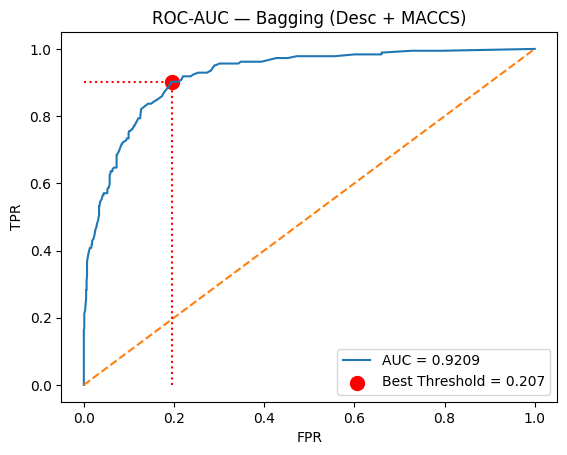

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


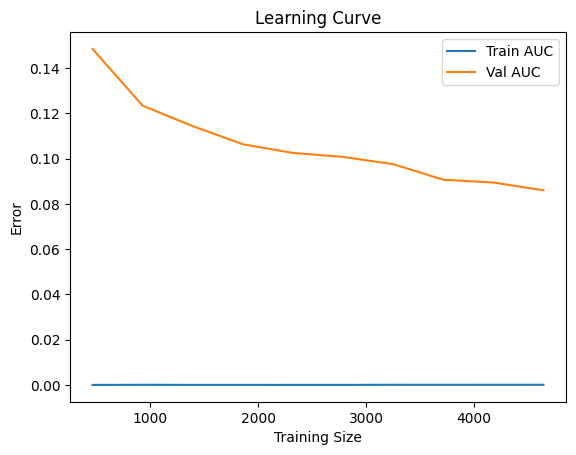

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


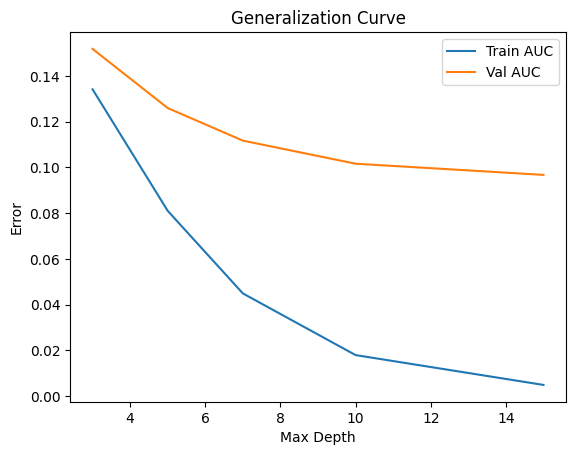


MODEL SUMMARY — BAGGING (Desc + morgan)

--- Test Performance ---
AUC: 0.921

--- Cross-Validation ---
CV Scores: [0.91963637 0.91337724 0.90946665 0.91249555 0.91632968]
Mean AUC: 0.914
Std AUC: 0.003
Approx 95% range: [0.907, 0.921]

--- Cost Analysis ---
[[787 190]
 [ 18 166]]
FP=190, FN=18
Best Threshold: 0.2067
Total Cost: 280


In [17]:
results_bagging_morgan = train_bagging_tree_model(results, assay_name="SR-MMP")

# Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def logistic_regression_pipeline(X_features, y, test_size=0.2, random_state=42, class_weight=None):

    c_fp = 1
    c_fn = 5

    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=test_size, random_state=random_state, stratify=y
    )

    param_grid = {
        "model__C":       [0.001, 0.01, 0.1, 1, 100],
        "model__penalty": ["l2"],
        "model__solver":  ["liblinear"],
        "model__max_iter":[1000],
    }

    base_pipeline = Pipeline([
        ("imputer",         SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=0)),
        ("scaler",          StandardScaler()),
        ("model",           LogisticRegression(
                                random_state=random_state,
                                class_weight=class_weight
                            )),
    ])

    grid = GridSearchCV(base_pipeline, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    model = grid.best_estimator_
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    E_in  = 1 - accuracy_score(y_train, y_train_pred)
    E_out = 1 - accuracy_score(y_test,  y_test_pred)

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)

    # ── ROC-AUC Curve ──────────────────────────────────────────────────────
    plt.figure()
    plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-AUC Curve — Logistic Regression")
    plt.legend()
    plt.show()

    # ── Cost-based threshold optimization ──────────────────────────────────
    best_threshold = 0.5
    best_cost      = float("inf")

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
        cost = (fp_t * c_fp) + (fn_t * c_fn)
        if cost < best_cost:
            best_cost      = cost
            best_threshold = t

    y_test_pred_tuned = (y_prob >= best_threshold).astype(int)
    cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
    TN_t, FP_t, FN_t, TP_t = cm_tuned.ravel()
    total_cost = (FP_t * c_fp) + (FN_t * c_fn)

    print("\n=== CONFUSION MATRIX + COST ANALYSIS ===")
    print("Confusion Matrix:\n", cm_tuned)
    print(f"TN={TN_t}  FP={FP_t}  FN={FN_t}  TP={TP_t}")
    print(f"False Positives: {FP_t}  Cost: {FP_t * c_fp}")
    print(f"False Negatives: {FN_t}  Cost: {FN_t * c_fn}")
    print(f"Total Cost: {total_cost}")
    print(f"Best Threshold: {best_threshold:.4f}  (Min Cost: {best_cost})")

    # ── Learning Curve ──────────────────────────────────────────────────────
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_features, y,
        cv=5, train_sizes=np.linspace(0.1, 1.0, 10), scoring="roc_auc"
    )
    plt.figure()
    plt.plot(train_sizes, 1 - np.mean(train_scores, axis=1), label="Training Error")
    plt.plot(train_sizes, 1 - np.mean(val_scores,   axis=1), label="Validation Error")
    plt.xlabel("Training Set Size")
    plt.ylabel("Error")
    plt.title("Learning Curve — Logistic Regression")
    plt.legend()
    plt.show()

    # ── Generalization Curve ────────────────────────────────────────────────
    param_range = [0.001, 0.01, 0.1, 1, 10, 100]

    gen_pipeline = Pipeline([
        ("imputer",         SimpleImputer(strategy="median")),
        ("variance_filter", VarianceThreshold(threshold=0)),
        ("scaler",          StandardScaler()),
        ("model",           LogisticRegression(
                                penalty="l2", solver="liblinear", max_iter=1000,
                                class_weight=class_weight, random_state=random_state
                            )),
    ])

    train_scores_v, val_scores_v = validation_curve(
        gen_pipeline, X_features, y,
        param_name="model__C", param_range=param_range, cv=5, scoring="roc_auc"
    )
    plt.figure()
    plt.plot(param_range, 1 - np.mean(train_scores_v, axis=1), label="Training Error")
    plt.plot(param_range, 1 - np.mean(val_scores_v,   axis=1), label="Validation Error")
    plt.xlabel("C (Regularization Strength)")
    plt.ylabel("Error")
    plt.title("Generalization Curve — Logistic Regression")
    plt.legend()
    plt.xscale("log")
    plt.show()

    if E_in < E_out - 0.05:
        interpretation = "Overfitting"
    elif abs(E_in - E_out) < 0.02:
        interpretation = "Good generalization"
    else:
        interpretation = "Possible underfitting or moderate variance"

    return {
        "model":                  model,
        "best_params":            grid.best_params_,
        "E_in":                   E_in,
        "E_out":                  E_out,
        "AUC":                    roc_auc,
        "best_threshold":         best_threshold,
        "total_cost":             total_cost,
        "confusion_matrix_tuned": cm_tuned,
        "TN_tuned": TN_t, "FP_tuned": FP_t,
        "FN_tuned": FN_t, "TP_tuned": TP_t,
        "interpretation":         interpretation,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
    }


LOGISTIC REGRESSION (Desc + MACCS)


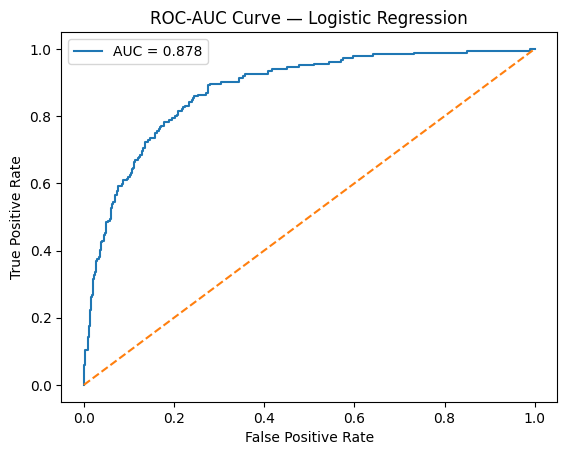


=== CONFUSION MATRIX + COST ANALYSIS ===
Confusion Matrix:
 [[738 239]
 [ 26 158]]
TN=738  FP=239  FN=26  TP=158
False Positives: 239  Cost: 239
False Negatives: 26  Cost: 130
Total Cost: 369
Best Threshold: 0.3408  (Min Cost: 369)


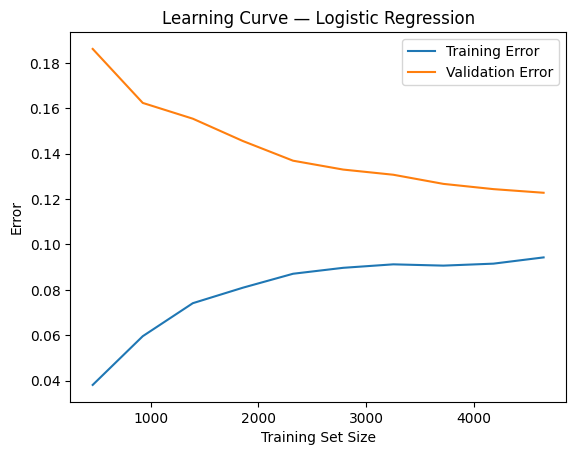

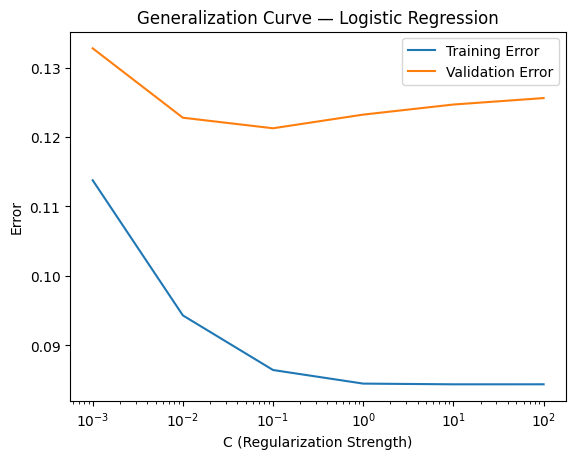


=== BENCHMARK (Desc + MACCS) ===
Model                            Accuracy        AUC
----------------------------------------------------
Random Predictor                   0.5022     0.5000
Majority Class                     0.8415     0.5000
Single Attribute                   0.8415     0.6539
Decision Tree (depth=2)            0.8415     0.7544
Your Model                         0.8432     0.8784 <-- YOURS
ASSAY comparision


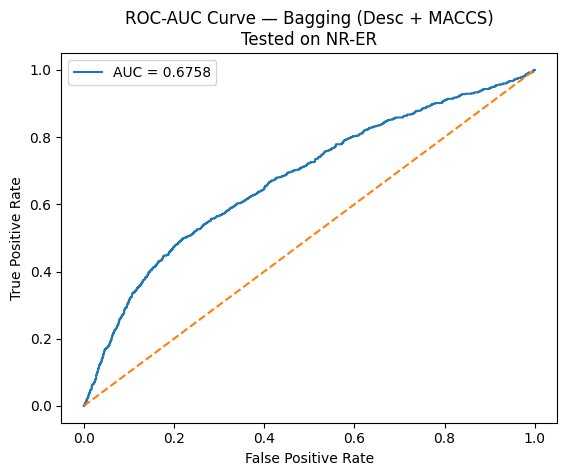

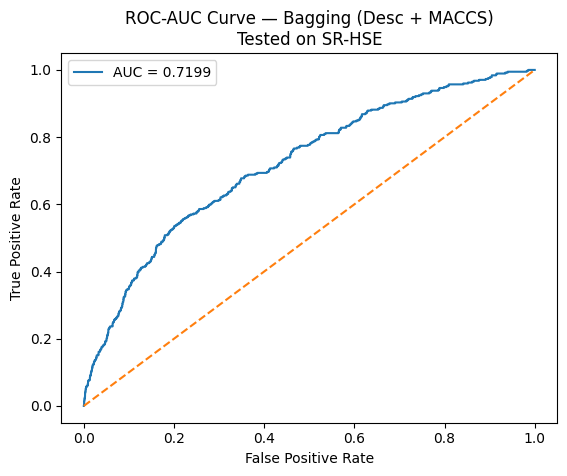

In [ ]:
# ==============================================================================
# LOGISTIC REGRESSION — Desc + MACCS
# ==============================================================================
print("=" * 60)
print("LOGISTIC REGRESSION (Desc + MACCS)")
print("=" * 60)

results_maccs_log = logistic_regression_pipeline(
    X_desc_maccs, y_desc, class_weight={0: 1, 1: 3}
)

print("\n=== BENCHMARK (Desc + MACCS) ===")
run_benchmarks(
    results_maccs_log["X_train"], results_maccs_log["X_test"],
    results_maccs_log["y_train"], results_maccs_log["y_test"],
    results_maccs_log
)



In [ ]:
# ==============================================================================
# LOGISTIC REGRESSION — Desc + Morgan
# ==============================================================================
print("=" * 60)
print("LOGISTIC REGRESSION (Desc + morgan)")
print("=" * 60)

results_morgan = logistic_regression_pipeline(
    X_desc_morgan, y_desc, class_weight={0: 1, 1: 3}
)

print("\n=== BENCHMARK (Desc + Morgan) ===")
run_benchmarks(
    results_morgan["X_train"], results_morgan["X_test"],
    results_morgan["y_train"], results_morgan["y_test"],
    results_morgan
)

print("ASSAY comparision")
best_logistic_model_morg = results_morgan_log["model"]



LOGISTIC REGRESSION (Desc + morgan)


KeyboardInterrupt: 

# Linear Model

In [ ]:
from sklearn.linear_model import SGDClassifier
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from joblib import Memory
from sklearn.preprocessing import StandardScaler

def run_SGD(X, y, folds, a):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('variance_threshold', VarianceThreshold(0.01)),
        ('model', SGDClassifier(loss="log_loss",
                                penalty="l2",
                                alpha=a,
                                random_state=42,
                                class_weight="balanced"))],
        memory=Memory(location="cache_dir", verbose=0))

    pipeline.fit(X, y)
    predictions = pipeline.predict(X)

    in_sample_error = sum(y != predictions) / len(y)
    scores = cross_val_score(pipeline, X, y, cv=folds)
    out_sample_error = 1 - sum(scores) / len(scores)

    return in_sample_error, out_sample_error


LINEAR CLASSIFIER (Desc + MACCS)


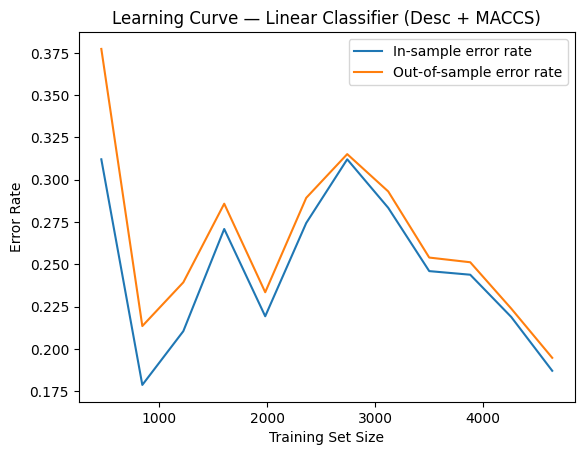

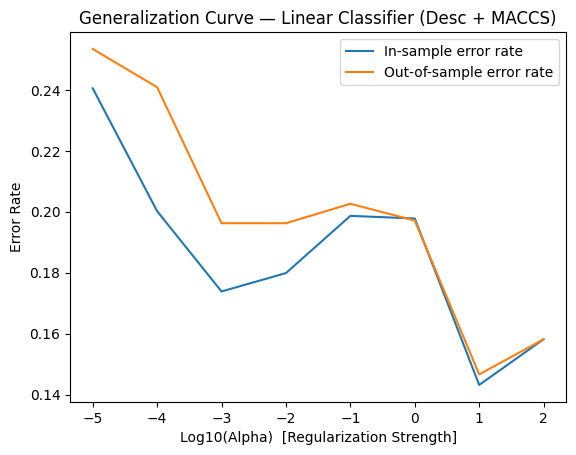

AUC (5-fold CV): mean=0.8461  SD=0.0139


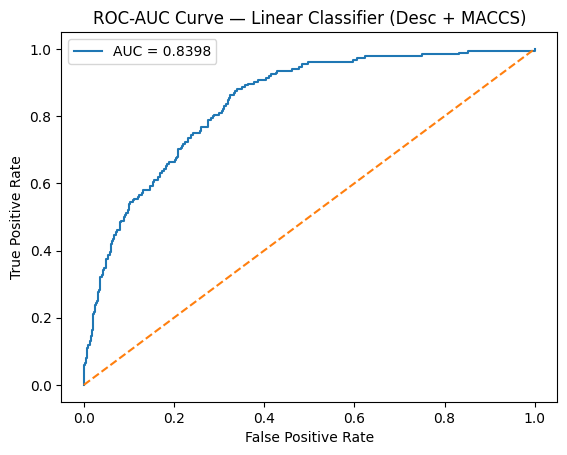


=== CONFUSION MATRIX + COST ANALYSIS (Desc + MACCS) ===
Confusion Matrix:
 [[646 331]
 [ 22 162]]
TN=646  FP=331  FN=22  TP=162
False Positives: 331  Cost: 331
False Negatives: 22  Cost: 110
Total Cost: 441
Best Threshold: 0.4330  (Min Cost: 441)

=== BENCHMARK (Desc + MACCS) ===
Model                            Accuracy        AUC
----------------------------------------------------
Random Predictor                   0.5022     0.5000
Majority Class                     0.8415     0.5000
Single Attribute                   0.8415     0.6539
Decision Tree (depth=2)            0.8415     0.7544
Your Model                         0.8029     0.8398 <-- YOURS


{'Random Predictor': {'accuracy': 0.5021533161068045, 'auc': np.float64(0.5)},
 'Majority Class': {'accuracy': 0.8415159345391904, 'auc': np.float64(0.5)},
 'Single Attribute': {'accuracy': 0.8415159345391904,
  'auc': np.float64(0.6538566374438165)},
 'Decision Tree (depth=2)': {'accuracy': 0.8415159345391904,
  'auc': np.float64(0.754372302078234)},
 'Your Model': {'accuracy': np.float64(0.8028884136742998),
  'auc': np.float64(0.8398213252636733)}}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from joblib import Memory

folds = 5
alpha = 1
c_fp  = 1
c_fn  = 5

log_alphas = np.array([-5, -4, -3, -2, -1, 0, 1, 2])
alphas     = 10.0 ** log_alphas

# ==============================================================================
# LINEAR CLASSIFIER — Desc + MACCS
# ==============================================================================
print("=" * 60)
print("LINEAR CLASSIFIER (Desc + MACCS)")
print("=" * 60)

X_train_maccs, X_test_maccs, y_train_maccs, y_test_maccs = train_test_split(
    X_desc_maccs, y_desc, test_size=0.2, stratify=y_desc, random_state=42)

pipeline_maccs = Pipeline([
    ('scaler',             StandardScaler()),
    ('variance_threshold', VarianceThreshold(0.01)),
    ('model',              SGDClassifier(loss="log_loss", penalty="l2",
                                         alpha=alpha, random_state=42,
                                         class_weight="balanced"))],
    memory=Memory(location="cache_dir", verbose=0))

# ── Learning Curve ─────────────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_maccs,
    X=X_desc_maccs, y=y_desc,
    cv=folds, train_sizes=np.linspace(0.1, 1.0, 12), n_jobs=-1)

plt.figure()
plt.plot(train_sizes, 1 - np.mean(train_scores, axis=1), label="In-sample error rate")
plt.plot(train_sizes, 1 - np.mean(val_scores,   axis=1), label="Out-of-sample error rate")
plt.xlabel("Training Set Size")
plt.ylabel("Error Rate")
plt.title("Learning Curve — Linear Classifier (Desc + MACCS)")
plt.legend()
plt.show()

# ── Generalization Curve ────────────────────────────────────────────────────
cgc_in_maccs  = [0] * len(alphas)
cgc_out_maccs = [0] * len(alphas)
for j, a in enumerate(alphas):
    cgc_in_maccs[j], cgc_out_maccs[j] = run_SGD(X_desc_maccs, y_desc, folds, a)

plt.figure()
plt.plot(log_alphas, cgc_in_maccs,  label="In-sample error rate")
plt.plot(log_alphas, cgc_out_maccs, label="Out-of-sample error rate")
plt.xlabel("Log10(Alpha)  [Regularization Strength]")
plt.ylabel("Error Rate")
plt.title("Generalization Curve — Linear Classifier (Desc + MACCS)")
plt.legend()
plt.show()

# ── ROC-AUC Curve ──────────────────────────────────────────────────────────
pipeline_maccs.fit(X_train_maccs, y_train_maccs)
y_prob_maccs = pipeline_maccs.predict_proba(X_test_maccs)[:, 1]
fpr_maccs, tpr_maccs, thresh_maccs = roc_curve(y_test_maccs, y_prob_maccs)
area_maccs = auc(fpr_maccs, tpr_maccs)

scores_maccs = cross_val_score(pipeline_maccs, X_desc_maccs, y_desc, scoring="roc_auc", cv=folds)
print(f"AUC (5-fold CV): mean={scores_maccs.mean():.4f}  SD={scores_maccs.std():.4f}")

plt.figure()
plt.plot(fpr_maccs, tpr_maccs, label=f"AUC = {area_maccs:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve — Linear Classifier (Desc + MACCS)")
plt.legend()
plt.show()

# ── Confusion Matrix with Costs ─────────────────────────────────────────────
best_t_maccs    = 0.5
best_cost_maccs = float("inf")
for t in thresh_maccs:
    y_pred_t = (y_prob_maccs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_maccs, y_pred_t).ravel()
    cost = fp * c_fp + fn * c_fn
    if cost < best_cost_maccs:
        best_cost_maccs = cost
        best_t_maccs    = t

y_pred_maccs = (y_prob_maccs >= best_t_maccs).astype(int)
cm_maccs = confusion_matrix(y_test_maccs, y_pred_maccs)
tn, fp, fn, tp = cm_maccs.ravel()

print("\n=== CONFUSION MATRIX + COST ANALYSIS (Desc + MACCS) ===")
print("Confusion Matrix:\n", cm_maccs)
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"False Positives: {fp}  Cost: {fp * c_fp}")
print(f"False Negatives: {fn}  Cost: {fn * c_fn}")
print(f"Total Cost: {fp * c_fp + fn * c_fn}")
print(f"Best Threshold: {best_t_maccs:.4f}  (Min Cost: {best_cost_maccs})")

# ── Benchmark ──────────────────────────────────────────────────────────────
in_err_maccs, out_err_maccs = run_SGD(X_desc_maccs, y_desc, folds, alpha)
sgd_maccs_results = {"E_out": out_err_maccs, "AUC": area_maccs}
print("\n=== BENCHMARK (Desc + MACCS) ===")
run_benchmarks(X_train_maccs, X_test_maccs, y_train_maccs, y_test_maccs, sgd_maccs_results)


LINEAR CLASSIFIER (Desc + Morgan)


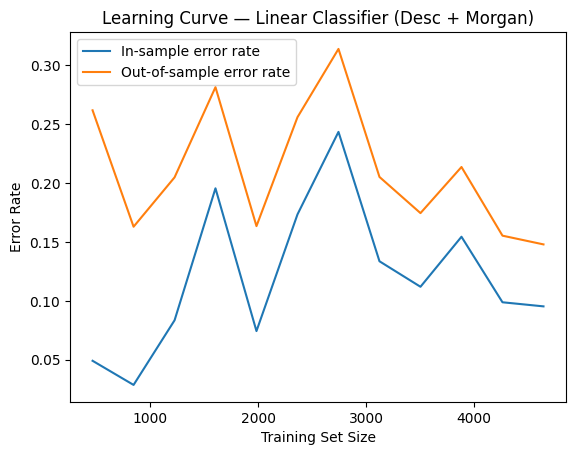

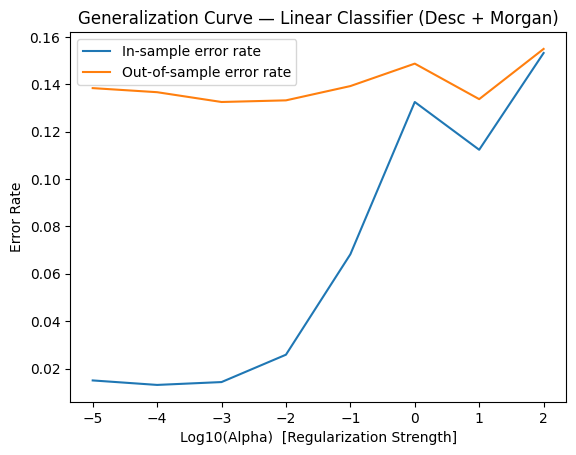

AUC (5-fold CV): mean=0.8765  SD=0.0079


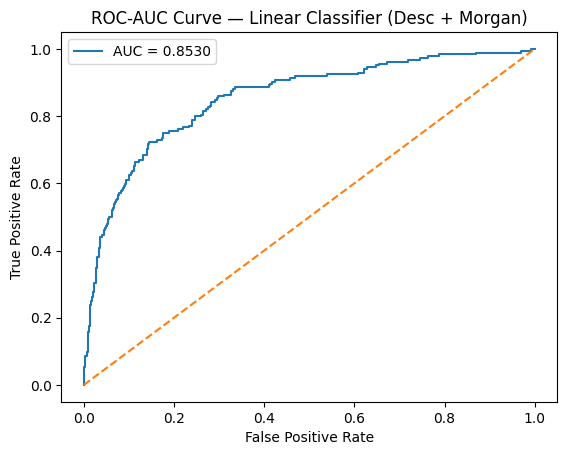


=== CONFUSION MATRIX + COST ANALYSIS (Desc + Morgan) ===
Confusion Matrix:
 [[836 141]
 [ 51 133]]
TN=836  FP=141  FN=51  TP=133
False Positives: 141  Cost: 141
False Negatives: 51  Cost: 255
Total Cost: 396
Best Threshold: 0.5319  (Min Cost: 396)

=== BENCHMARK (Desc + Morgan) ===
Model                            Accuracy        AUC
----------------------------------------------------
Random Predictor                   0.5022     0.5000
Majority Class                     0.8415     0.5000
Single Attribute                   0.8475     0.5455
Decision Tree (depth=2)            0.8613     0.7677
Your Model                         0.8513     0.8530 <-- YOURS


{'Random Predictor': {'accuracy': 0.5021533161068045, 'auc': np.float64(0.5)},
 'Majority Class': {'accuracy': 0.8415159345391904, 'auc': np.float64(0.5)},
 'Single Attribute': {'accuracy': 0.8475452196382429,
  'auc': np.float64(0.5454891860620354)},
 'Decision Tree (depth=2)': {'accuracy': 0.8613264427217916,
  'auc': np.float64(0.767700591873971)},
 'Your Model': {'accuracy': np.float64(0.8513115922658825),
  'auc': np.float64(0.8530272351030217)}}

In [ ]:
# ==============================================================================
# LINEAR CLASSIFIER — Desc + Morgan
# ==============================================================================
print("=" * 60)
print("LINEAR CLASSIFIER (Desc + Morgan)")
print("=" * 60)

X_train_morgan, X_test_morgan, y_train_morgan, y_test_morgan = train_test_split(
    X_desc_morgan, y_desc, test_size=0.2, stratify=y_desc, random_state=42)

pipeline_morgan = Pipeline([
    ('scaler',             StandardScaler()),
    ('variance_threshold', VarianceThreshold(0.01)),
    ('model',              SGDClassifier(loss="log_loss", penalty="l2",
                                          alpha=alpha, random_state=42,
                                          class_weight="balanced"))],
    memory=Memory(location="cache_dir", verbose=0))

# ── Learning Curve ─────────────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_morgan,
    X=X_desc_morgan, y=y_desc,
    cv=folds, train_sizes=np.linspace(0.1, 1.0, 12), n_jobs=-1)

plt.figure()
plt.plot(train_sizes, 1 - np.mean(train_scores, axis=1), label="In-sample error rate")
plt.plot(train_sizes, 1 - np.mean(val_scores,   axis=1), label="Out-of-sample error rate")
plt.xlabel("Training Set Size")
plt.ylabel("Error Rate")
plt.title("Learning Curve — Linear Classifier (Desc + Morgan)")
plt.legend()
plt.show()

# ── Generalization Curve ────────────────────────────────────────────────────
cgc_in_morgan  = [0] * len(alphas)
cgc_out_morgan = [0] * len(alphas)
for j, a in enumerate(alphas):
    cgc_in_morgan[j], cgc_out_morgan[j] = run_SGD(X_desc_morgan, y_desc, folds, a)

plt.figure()
plt.plot(log_alphas, cgc_in_morgan,  label="In-sample error rate")
plt.plot(log_alphas, cgc_out_morgan, label="Out-of-sample error rate")
plt.xlabel("Log10(Alpha)  [Regularization Strength]")
plt.ylabel("Error Rate")
plt.title("Generalization Curve — Linear Classifier (Desc + Morgan)")
plt.legend()
plt.show()

# ── ROC-AUC Curve ──────────────────────────────────────────────────────────
pipeline_morgan.fit(X_train_morgan, y_train_morgan)
y_prob_morgan = pipeline_morgan.predict_proba(X_test_morgan)[:, 1]
fpr_morgan, tpr_morgan, thresh_morgan = roc_curve(y_test_morgan, y_prob_morgan)
area_morgan = auc(fpr_morgan, tpr_morgan)

scores_morgan = cross_val_score(pipeline_morgan, X_desc_morgan, y_desc, scoring="roc_auc", cv=folds)
print(f"AUC (5-fold CV): mean={scores_morgan.mean():.4f}  SD={scores_morgan.std():.4f}")

plt.figure()
plt.plot(fpr_morgan, tpr_morgan, label=f"AUC = {area_morgan:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve — Linear Classifier (Desc + Morgan)")
plt.legend()
plt.show()

# ── Confusion Matrix with Costs ─────────────────────────────────────────────
best_t_morgan    = 0.5
best_cost_morgan = float("inf")
for t in thresh_morgan:
    y_pred_t = (y_prob_morgan >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_morgan, y_pred_t).ravel()
    cost = fp * c_fp + fn * c_fn
    if cost < best_cost_morgan:
        best_cost_morgan = cost
        best_t_morgan    = t

y_pred_morgan = (y_prob_morgan >= best_t_morgan).astype(int)
cm_morgan = confusion_matrix(y_test_morgan, y_pred_morgan)
tn, fp, fn, tp = cm_morgan.ravel()

print("\n=== CONFUSION MATRIX + COST ANALYSIS (Desc + Morgan) ===")
print("Confusion Matrix:\n", cm_morgan)
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"False Positives: {fp}  Cost: {fp * c_fp}")
print(f"False Negatives: {fn}  Cost: {fn * c_fn}")
print(f"Total Cost: {fp * c_fp + fn * c_fn}")
print(f"Best Threshold: {best_t_morgan:.4f}  (Min Cost: {best_cost_morgan})")

# ── Benchmark ──────────────────────────────────────────────────────────────
in_err_morgan, out_err_morgan = run_SGD(X_desc_morgan, y_desc, folds, alpha)
sgd_morgan_results = {"E_out": out_err_morgan, "AUC": area_morgan}
print("\n=== BENCHMARK (Desc + Morgan) ===")
run_benchmarks(X_train_morgan, X_test_morgan, y_train_morgan, y_test_morgan, sgd_morgan_results)

# Random Forest with Statistics (NOT used)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    learning_curve,
    validation_curve
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    roc_curve,
    auc
)
from sklearn.feature_selection import SelectKBest, f_classif


def train_random_forest_model_v2(X, y):

    # cost
    c_fp = 1
    c_fn = 5

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = pd.DataFrame(X_train)
    X_test  = pd.DataFrame(X_test)

    # corelation filtering
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

    X_train = X_train.drop(columns=to_drop)
    X_test  = X_test.drop(columns=to_drop)

    print(f"Removed {len(to_drop)} correlated features")

    # statistical selection...
    k = min(50, X_train.shape[1])  # keep top 50 or fewer
    selector = SelectKBest(score_func=f_classif, k=k)

    X_train = selector.fit_transform(X_train, y_train)
    X_test  = selector.transform(X_test)

    print(f"Selected top {X_train.shape[1]} features using ANOVA")

    # rf model
    rf = RandomForestClassifier(
        random_state=42,
        bootstrap=True,
        n_jobs=-1
    )

    param_grid = {
        "n_estimators":      [300, 500],
        "max_depth":         [10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf":  [1, 2, 5, 10],
        "max_features":      ["sqrt"],
        "class_weight":      ["balanced"]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    #train
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    # probability
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # optimize thresh
    thresholds = np.arange(0.1, 0.9, 0.01)

    best_threshold = 0.5
    best_cost = float("inf")

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        cost = (fp * c_fp) + (fn * c_fn)

        if cost < best_cost:
            best_cost = cost
            best_threshold = t

    y_pred = (y_prob >= best_threshold).astype(int)

    #the metrics
    acc     = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fp * c_fp) + (fn * c_fn)

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(cm)

    print("\n=== METRICS ===")
    print("Accuracy:", acc)
    print("ROC AUC:", roc_auc)

    print("\n=== COST ANALYSIS ===")
    print("False Positives:", fp, "Cost:", fp * c_fp)
    print("False Negatives:", fn, "Cost:", fn * c_fn)
    print("TOTAL COST:", total_cost)
    print("Best Threshold:", best_threshold)

    #roc curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # \learning curve
    analysis_model = RandomForestClassifier(**best_params, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=analysis_model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_error = 1 - np.mean(train_scores, axis=1)
    val_error   = 1 - np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_error, label="Training Error")
    plt.plot(train_sizes, val_error, label="Validation Error")
    plt.xlabel("Training Size")
    plt.ylabel("Error")
    plt.title("Learning Curve")
    plt.legend()
    plt.show()

    # val curve
    param_range = [5, 10, 20, 40, None]
    x_labels = ["5", "10", "20", "40", "None"]

    train_scores, val_scores = validation_curve(
        estimator=analysis_model,
        X=X_train,
        y=y_train,
        param_name="max_depth",
        param_range=param_range,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    train_error = 1 - np.mean(train_scores, axis=1)
    val_error   = 1 - np.mean(val_scores, axis=1)

    plt.figure()
    plt.plot(x_labels, train_error, label="Training Error")
    plt.plot(x_labels, val_error, label="Validation Error")
    plt.xlabel("max_depth")
    plt.ylabel("Error")
    plt.title("Validation Curve")
    plt.legend()
    plt.show()


    # results
    return {
        "model": best_model,
        "best_params": best_params,
        "best_threshold": best_threshold,
        "accuracy": acc,
        "roc_auc": roc_auc,
        "total_cost": total_cost,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
    }

# Testing Percision (NOT INCLUDED)

In [ ]:
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)


def train_bagging_precision_model(X, y, target_precision=0.90):

    # cost
    c_fp = 1
    c_fn = 5

    # train/test/split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    #param search
    param_dist = {
        "n_estimators": [50, 100, 150],
        "max_samples": [0.7, 1.0],
        "max_features": [0.7, 1.0],
        "estimator__max_depth": [5, 10, None],
        "estimator__min_samples_leaf": [1, 2, 5],
    }

    # Model/search
    search = RandomizedSearchCV(
        estimator=BaggingClassifier(
            estimator=DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            ),
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        param_distributions=param_dist,
        n_iter=25,
        cv=3,
        scoring="average_precision",
        n_jobs=-1,
        random_state=42,
        verbose=2
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("\nBest Params:", search.best_params_)

    #Probab
    y_prob = best_model.predict_proba(X_test)[:, 1]

    #Mertric
    roc_auc = roc_auc_score(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    print("\n=== PERFORMANCE ===")
    print(f"ROC-AUC: {roc_auc:.3f}")
    print(f"Average Precision (PR-AUC): {ap_score:.3f}")


    # THRESHOLD OPTIMIZATION (precsion target)

    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    valid_idx = np.where(precision[:-1] >= target_precision)[0]

    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmax(recall[valid_idx])]
        best_threshold = thresholds[best_idx]
    else:
        best_threshold = 0.5


    # FINAL PREDICTIONS

    y_pred = (y_prob >= best_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred)

    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0

    total_cost = fp * c_fp + fn * c_fn

    print("\n=== CONFUSION MATRIX ===")
    print(cm)

    print("\n=== CLASS 1 METRICS ===")
    print(f"Precision: {precision_final:.3f}")
    print(f"Recall:    {recall_final:.3f}")

    print("\n=== THRESHOLD + COST ===")
    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Total Cost: {total_cost}")


    # CROSS-VALIDATION

    cv_scores = cross_val_score(
        best_model,
        X,
        y,
        scoring="average_precision",
        cv=5,
        n_jobs=-1
    )

    print("\n=== CROSS-VALIDATION (PR-AUC) ===")
    print("Scores:", cv_scores)
    print(f"Mean: {np.mean(cv_scores):.3f}")
    print(f"Std:  {np.std(cv_scores):.3f}")
    print(f"95% range: [{np.mean(cv_scores)-2*np.std(cv_scores):.3f}, "
          f"{np.mean(cv_scores)+2*np.std(cv_scores):.3f}]")


    # RETURN

    return {
        "model": best_model,
        "roc_auc": roc_auc,
        "average_precision": ap_score,
        "best_threshold": best_threshold,
        "confusion_matrix": cm,
        "precision": precision_final,
        "recall": recall_final,
        "cv_scores": cv_scores,
        "cv_mean": np.mean(cv_scores),
        "cv_std": np.std(cv_scores)
    }

In [ ]:
results_perc_bag = train_bagging_precision_model(X_desc_maccs, y_desc, target_precision=0.75)

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Params: {'n_estimators': 150, 'max_samples': 1.0, 'max_features': 0.7, 'estimator__min_samples_leaf': 1, 'estimator__max_depth': None}

=== PERFORMANCE ===
ROC-AUC: 0.929
Average Precision (PR-AUC): 0.754

=== CONFUSION MATRIX ===
[[942  35]
 [ 76 108]]

=== CLASS 1 METRICS ===
Precision: 0.755
Recall:    0.587

=== THRESHOLD + COST ===
Best Threshold: 0.4133
Total Cost: 415

=== CROSS-VALIDATION (PR-AUC) ===
Scores: [0.80076357 0.71004508 0.72708358 0.74829956 0.73079117]
Mean: 0.743
Std:  0.031
95% range: [0.681, 0.806]


In [ ]:
best_per_model = results_perc_bag["model"]

for assay_name in results:

    # skip training assay
    if assay_name == "SR-MMP":
        continue

    X_test = results[assay_name]["X_desc_maccs"]
    y_test = results[assay_name]["y_desc"]

    y_prob =best_per_model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC-AUC Curve — Bagging (Desc + MACCS)\nTested on {assay_name}")
    plt.legend()
    plt.show()

NameError: name 'roc_curve' is not defined

#